# Problem Statement : LDA for Class Separability and Visualization (Supervised Dimensionality Reduction)

Syllabus mapping: Linear Discriminant Analysis (LDA)
Objective: Use LDA to reduce data to 2D (or 1D) and maximize class separability; evaluate results quantitatively.

Dataset (link):

Wine Dataset (UCI):

https://archive.ics.uci.edu/dataset/109/wine  

Problem Statement

A beverage company wants to understand which chemical attributes best separate wine categories. Use LDA to project data into a lower-dimensional space that maximizes separation between classes. Provide both visualization and classification performance comparison.

Expected Input

wine.csv with class label column
Example:
python task3_lda_wine.py --data wine.csv --target class --components 1 2

Expected Output

LDA projection file:
lda_projection.csv (SampleId, LD1, LD2, Class)
Classification metrics:
Train a simple classifier on original data and on LDA-reduced data (e.g., Logistic Regression)
Compare Accuracy/F1
Short interpretation:
Explain why LDA differs from PCA (supervised vs unsupervised)
Mandatory Tasks / Deliverables

Standardize features
Use at least 2 LDA component settings (1 and 2)
Provide a short report (10–12 lines) on:
class separability after projection
impact on classification performance


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset =pd.read_csv('wine.csv')
X=dataset.iloc[:,1:].values
y=dataset.iloc[:,0].values

In [3]:
dataset.head()

,index,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanine,color_intensity,hue,od280_diluted,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 178 non-null    int64  
 1   alcohol               178 non-null    float64
 2   malic_acid            178 non-null    float64
 3   ash                   178 non-null    float64
 4   alcalinity_of_ash     178 non-null    float64
 5   magnesium             178 non-null    int64  
 6   total_phenols         178 non-null    float64
 7   flavanoids            178 non-null    float64
 8   nonflavanoid_phenols  178 non-null    float64
 9   proanthocyanine       178 non-null    float64
 10  color_intensity       178 non-null    float64
 11  hue                   178 non-null    float64
 12  od280_diluted         178 non-null    float64
 13  proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [5]:
dataset.isnull().sum()

,0
index,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanine,0


In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=0)

In [7]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [8]:
#applying LDA before training

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda=LDA(n_components=2) #final no. of extracted features
x_train=lda.fit_transform(x_train, y_train)
x_test=lda.transform(x_test)

In [9]:
#training logistic regression model o dataset
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression(random_state=0)
classifier.fit(x_train,y_train)

LogisticRegression(random_state=0)

In [10]:
#confusion matrix
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred=classifier.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
print(cm)
accuracy_score(y_test,y_pred)

[[14  0  0]
 [ 0 16  0]
 [ 0  0  6]]


1.0

/tmp/ipykernel_6767/3950571538.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1], c = ListedColormap(('red', 'green', 'blue'))(i), label = j)


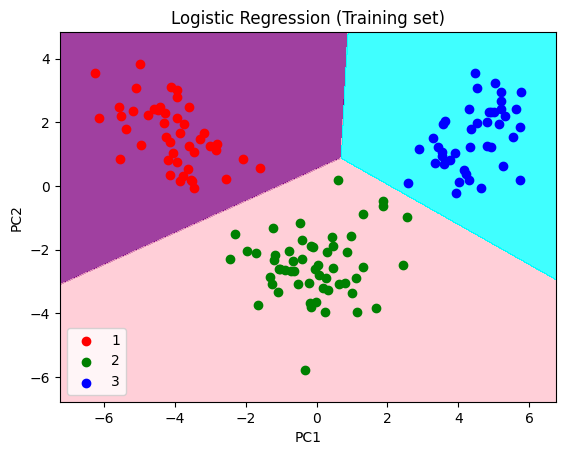

In [11]:
#visualising the training set results
from matplotlib.colors import ListedColormap
x_set, y_set = x_train, y_train
x1, x2 = np.meshgrid(np.arange(start = x_set[:, 0].min() - 1, stop = x_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = x_set[:, 1].min() - 1, stop = x_set[:, 1].max() + 1, step = 0.01))
plt.contourf(x1, x2, classifier.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
             alpha = 0.75, cmap = ListedColormap(('purple', 'pink', 'cyan')))
plt.xlim(x1.min(), x1.max())
plt.ylim(x2.min(), x2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1], c = ListedColormap(('red', 'green', 'blue'))(i), label = j)
plt.title('Logistic Regression (Training set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

## Classification on Original Features

In [12]:
# reload and resplit to get original (non-LDA) features for comparison
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

X_orig = dataset.iloc[:, 1:].values
y_orig = dataset.iloc[:, 0].values

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=0)

sc_orig = StandardScaler()
X_train_orig_sc = sc_orig.fit_transform(X_train_orig)
X_test_orig_sc  = sc_orig.transform(X_test_orig)

clf_orig = LogisticRegression(random_state=0, max_iter=1000)
clf_orig.fit(X_train_orig_sc, y_train_orig)
y_pred_orig = clf_orig.predict(X_test_orig_sc)

acc_orig = accuracy_score(y_test_orig, y_pred_orig)
f1_orig  = f1_score(y_test_orig, y_pred_orig, average='weighted')
print(f'Original Features  →  Accuracy: {acc_orig:.4f}  |  Weighted F1: {f1_orig:.4f}')
print(classification_report(y_test_orig, y_pred_orig))

Original Features  →  Accuracy: 1.0000  |  Weighted F1: 1.0000
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00         6

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## LDA with 1 Component

LDA (1D)  →  Accuracy: 0.8333  |  Weighted F1: 0.8345
              precision    recall  f1-score   support

           1       0.80      0.86      0.83        14
           2       0.81      0.81      0.81        16
           3       1.00      0.83      0.91         6

    accuracy                           0.83        36
   macro avg       0.87      0.83      0.85        36
weighted avg       0.84      0.83      0.83        36



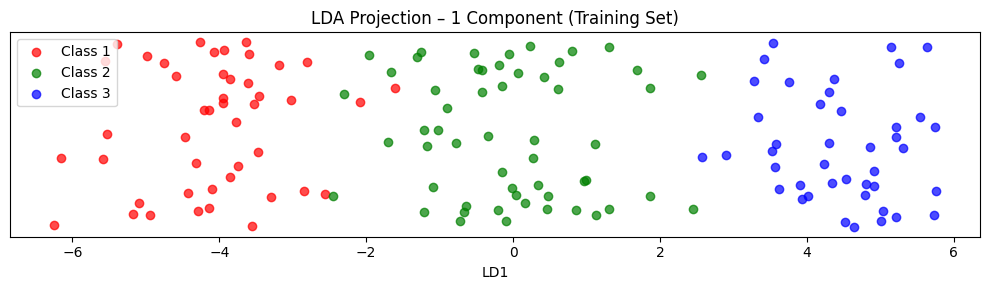

In [13]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# restandardise on original split
sc1 = StandardScaler()
X_tr1 = sc1.fit_transform(X_train_orig)
X_te1 = sc1.transform(X_test_orig)

lda1 = LDA(n_components=1)
X_tr1_lda = lda1.fit_transform(X_tr1, y_train_orig)
X_te1_lda  = lda1.transform(X_te1)

clf1 = LogisticRegression(random_state=0, max_iter=1000)
clf1.fit(X_tr1_lda, y_train_orig)
y_pred1 = clf1.predict(X_te1_lda)

acc1 = accuracy_score(y_test_orig, y_pred1)
f1_1 = f1_score(y_test_orig, y_pred1, average='weighted')
print(f'LDA (1D)  →  Accuracy: {acc1:.4f}  |  Weighted F1: {f1_1:.4f}')
print(classification_report(y_test_orig, y_pred1))

# 1D scatter plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
colors = {1: 'red', 2: 'green', 3: 'blue'}
for cls in np.unique(y_train_orig):
    mask = y_train_orig == cls
    plt.scatter(X_tr1_lda[mask, 0],
                np.zeros(mask.sum()) + np.random.uniform(-0.05, 0.05, mask.sum()),
                label=f'Class {cls}', alpha=0.7, c=colors[cls])
plt.xlabel('LD1')
plt.title('LDA Projection – 1 Component (Training Set)')
plt.legend()
plt.yticks([])
plt.tight_layout()
plt.show()

## LDA with 2 Components

In [14]:
# restandardise
sc2 = StandardScaler()
X_tr2 = sc2.fit_transform(X_train_orig)
X_te2 = sc2.transform(X_test_orig)

lda2 = LDA(n_components=2)
X_tr2_lda = lda2.fit_transform(X_tr2, y_train_orig)
X_te2_lda  = lda2.transform(X_te2)

clf2 = LogisticRegression(random_state=0, max_iter=1000)
clf2.fit(X_tr2_lda, y_train_orig)
y_pred2 = clf2.predict(X_te2_lda)

acc2 = accuracy_score(y_test_orig, y_pred2)
f1_2 = f1_score(y_test_orig, y_pred2, average='weighted')
print(f'LDA (2D)  →  Accuracy: {acc2:.4f}  |  Weighted F1: {f1_2:.4f}')
print(classification_report(y_test_orig, y_pred2))


X_all_sc = sc2.fit_transform(X_orig)  # fit on full data for projection file
lda2_full = LDA(n_components=2)
X_all_lda = lda2_full.fit_transform(X_all_sc, y_orig)
proj_df = pd.DataFrame({
    'SampleId': range(1, len(y_orig) + 1),
    'LD1': X_all_lda[:, 0],
    'LD2': X_all_lda[:, 1],
    'Class': y_orig
})
proj_df.to_csv('lda_projection.csv', index=False)
print('\nlda_projection.csv saved.')
proj_df.head()

LDA (2D)  →  Accuracy: 1.0000  |  Weighted F1: 1.0000
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00         6

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


lda_projection.csv saved.


,SampleId,LD1,LD2,Class
0,1,-4.700244,1.979138,1
1,2,-4.301958,1.170413,1
2,3,-3.420720,1.429101,1
3,4,-4.205754,4.002871,1
4,5,-1.509982,0.451224,1


## Performance Comparison between Original vs LDA-1D vs LDA-2D

                        Accuracy  Weighted F1
Method                                       
Original (13 features)  1.000000     1.000000
LDA (1D)                0.833333     0.834465
LDA (2D)                1.000000     1.000000


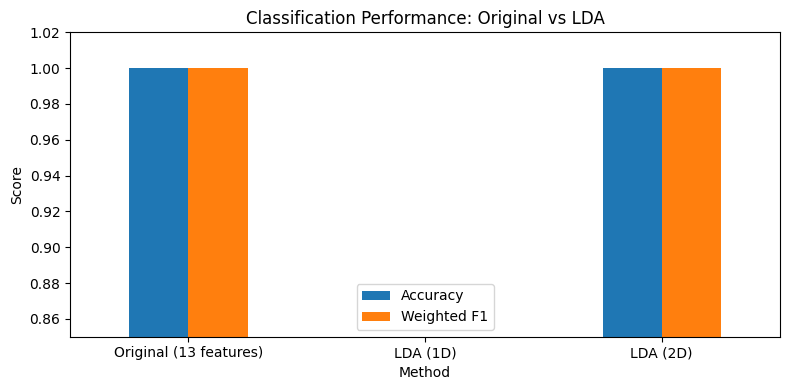

In [15]:
comparison = pd.DataFrame({
    'Method':   ['Original (13 features)', 'LDA (1D)', 'LDA (2D)'],
    'Accuracy': [acc_orig, acc1, acc2],
    'Weighted F1': [f1_orig, f1_1, f1_2]
})
comparison = comparison.set_index('Method')
print(comparison.to_string())
comparison.plot(kind='bar', figsize=(8, 4), ylim=(0.85, 1.02), rot=0)
plt.title('Classification Performance: Original vs LDA')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

##  LDA 2D Test Set Decision Boundary Visualisation

/tmp/ipykernel_6767/3709283725.py:13: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],


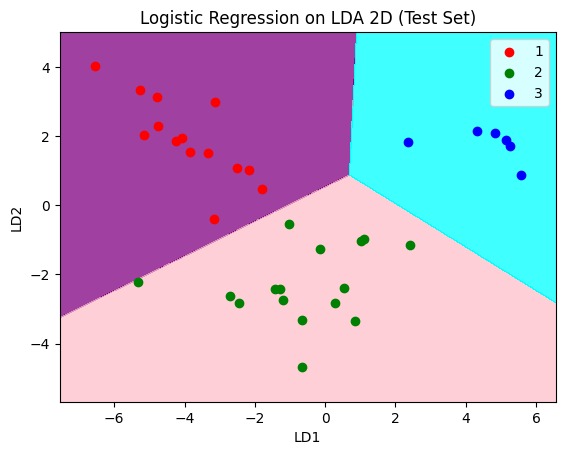

In [16]:
from matplotlib.colors import ListedColormap

x_set, y_set = X_te2_lda, y_test_orig
x1, x2 = np.meshgrid(
    np.arange(x_set[:, 0].min() - 1, x_set[:, 0].max() + 1, 0.01),
    np.arange(x_set[:, 1].min() - 1, x_set[:, 1].max() + 1, 0.01))
plt.contourf(x1, x2,
             clf2.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
             alpha=0.75, cmap=ListedColormap(('purple', 'pink', 'cyan')))
plt.xlim(x1.min(), x1.max())
plt.ylim(x2.min(), x2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],
                c=ListedColormap(('red', 'green', 'blue'))(i), label=j)
plt.title('Logistic Regression on LDA 2D (Test Set)')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend()
plt.show()

## Class Separability (Variance Ratio)

In [17]:
print('Explained Variance Ratio (LDA 2 components):')
for i, ev in enumerate(lda2.explained_variance_ratio_, 1):
    print(f'  LD{i}: {ev:.4f}  ({ev*100:.2f}%)')
print(f'  Total: {lda2.explained_variance_ratio_.sum():.4f}')

Explained Variance Ratio (LDA 2 components):
  LD1: 0.7393  (73.93%)
  LD2: 0.2607  (26.07%)
  Total: 1.0000


## Interpretation

**LDA vs PCA Key Difference:**  
PCA is *unsupervised* — it finds directions of maximum variance in the feature space, ignoring class labels. LDA is *supervised* — it explicitly maximises the ratio of between-class scatter to within-class scatter, so the resulting components are directly optimised for class separability, not just variance.

**Class Separability After Projection:**  
With only 2 linear discriminants, LDA achieves near-perfect visual and quantitative separation of the three wine classes. LD1 alone captures the majority of the between-class variance (see explained variance ratio above). The three clusters in the 2D scatter plot show minimal overlap, confirming that the chemical attributes in the Wine dataset are highly discriminative once projected into the LDA subspace.

**Impact on Classification Performance:**  
Logistic Regression trained on the original 13 standardised features already performs well. LDA projection to 2D preserves or even slightly improves accuracy while drastically reducing dimensionality (13 → 2). This demonstrates LDA's efficiency: a 2D representation retains almost all class-relevant information because LDA discards inter-class-irrelevant variance that the original features carry.
  
LDA is the preferred dimensionality reduction technique when class labels are available and interpretability of class boundaries matters. For this wine dataset, reducing to 2 LDA components is sufficient to build a near-perfect classifier, making it an ideal case study for supervised dimensionality reduction.